<a href="https://colab.research.google.com/github/dyn0x/test-aadya/blob/main/aadya_m1_playground2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# aadya-m1 playground

Run the open model **aadya-m1** yourself and test it like a user would: make forecasts, build a fresh test dataset, score the model against simple methods, and check calibration, missed logs, the optional ovulation-test input, personalization and edge cases. Everything uses libraries Colab already has (numpy, pandas, matplotlib, scipy, torch), so there is nothing extra to install. Nothing you type is sent anywhere except the one-time download of the public model weights.

**How to run:** `Runtime > Run all` (a GPU is optional, it just makes section 4 faster). Every section has its own plots. Total time: about 5 to 10 minutes.

> **Not a medical device.** aadya-m1 forecasts when a period is likely to start. It does not diagnose, and it gives no contraception or fertility advice. The test data below is **synthetic**: it checks the model's behaviour, it is not evidence about real people.

## 1. Setup and load the model

In [1]:
# Colab already has numpy, pandas, matplotlib, scipy and torch. Nothing else is installed
# unless it is missing (normally nothing happens here).
import importlib.util, subprocess, sys
for _pkg in ("safetensors", "huggingface_hub"):
    if importlib.util.find_spec(_pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", _pkg], check=False)

In [2]:
import sys, time, json, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import snapshot_download

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CORAL, BLUE, GREY, INK = "#e85d4c", "#2b6cb0", "#9aa5b1", "#15202b"
OUT = "aadya_results"; os.makedirs(OUT, exist_ok=True)

MODEL_ID = "manasdutta04/aadya-m1"
path = snapshot_download(MODEL_ID)          # about 1.5 GB, downloaded once
sys.path.insert(0, path)
sys.path.insert(0, os.path.join(path, "runtime"))   # the model's bundled code
from aadya_m1 import AadyaM1

device = "cuda" if torch.cuda.is_available() else "cpu"
t0 = time.time()
model = AadyaM1.from_pretrained(path, device=device)
print(f"loaded {MODEL_ID} on {device} in {time.time() - t0:.1f}s")

K = 120
ks = np.arange(1, K + 1)

def save(fig, name):
    fig.savefig(f"{OUT}/{name}.png", bbox_inches="tight")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 42 files:   0%|          | 0/42 [00:00<?, ?it/s]

loaded manasdutta04/aadya-m1 on cuda in 1.4s


## 2. Your first forecast

The model returns a **probability for every possible cycle length** (1 to 120 days), so an app can show a window instead of one date. `days_since_last_period` is 0 on the day a period starts.

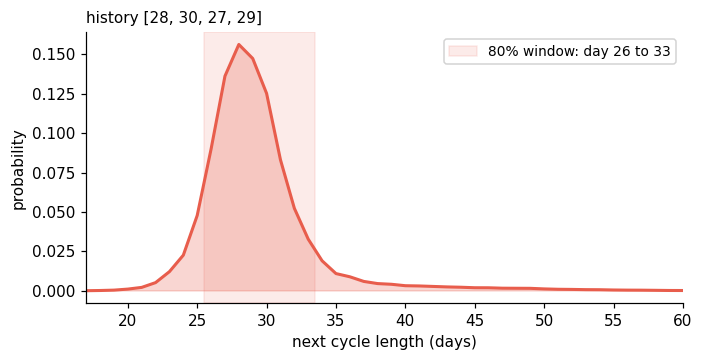

Most likely length: 28 days. About 8 in 10 chance the next period starts between day 26 and day 33.
Probabilities sum to 1.0


In [3]:
def plot_forecast(past, elapsed=0, age=None, marker=None, ax=None, title=None):
    pmf = model.forecast(past, days_since_last_period=elapsed, age_group=age, ovulation_test_day=marker)
    lo, hi = model.window(pmf)
    ax = ax or plt.subplots(figsize=(7, 3.2))[1]
    ax.axvspan(lo - 0.5, hi + 0.5, color=CORAL, alpha=0.12, label=f"80% window: day {lo} to {hi}")
    ax.fill_between(ks, pmf, color=CORAL, alpha=0.25)
    ax.plot(ks, pmf, color=CORAL, lw=2)
    ax.set_xlim(max(1, min(past, default=28) - 10 if past else 10), 60)
    ax.set_xlabel("next cycle length (days)"); ax.set_ylabel("probability")
    ax.set_title(title or f"history {past[-6:]}" + (f", day {elapsed}" if elapsed else ""), fontsize=10, loc="left")
    ax.legend(frameon=True, framealpha=0.85, fontsize=9, loc="upper right")
    return pmf

pmf = plot_forecast([28, 30, 27, 29])
plt.show()
lo, hi = model.window(pmf)
print(f"Most likely length: {int(np.argmax(pmf)) + 1} days. About 8 in 10 chance the next period starts between day {lo} and day {hi}.")
print("Probabilities sum to", round(float(pmf.sum()), 6))

## 3. Try your own input (interactive)

Type a history of past cycle lengths (days between period starts, oldest first), move the slider as days pass, and watch the window change.

In [4]:
try:
    import ipywidgets as w
    from IPython.display import display

    hist_w = w.Text(value="28, 30, 27, 29", description="Cycles", layout=w.Layout(width="420px"))
    day_w = w.IntSlider(value=0, min=0, max=60, description="Day now")
    age_w = w.Dropdown(options=[None, "18-24", "25-34", "35-44", "45+"], value=None, description="Age group")
    mk_w = w.IntText(value=0, description="Ovulation test day (0 = none)", style={"description_width": "initial"})
    out_w = w.Output()

    def refresh(*_):
        with out_w:
            out_w.clear_output(wait=True)
            try:
                past = [int(x) for x in hist_w.value.replace(";", ",").split(",") if x.strip()]
                mk = mk_w.value if mk_w.value > 0 else None
                plot_forecast(past, day_w.value, age_w.value, mk)
                plt.show()
            except Exception as e:  # show the model's own validation message
                print("Input problem:", e)

    for c in (hist_w, day_w, age_w, mk_w):
        c.observe(refresh, names="value")
    display(w.VBox([hist_w, day_w, age_w, mk_w, out_w]))
    refresh()
except ImportError:
    print("ipywidgets not available; use plot_forecast([...]) directly.")

## 4. Build a fresh test dataset

We generate **new synthetic users** with a seed the model has never seen, in seven deliberately different groups: regular, mildly irregular, very irregular (with occasional very long cycles), short cycles, long cycles, a skewed group whose cycles are mostly short with an uneven long tail (not a bell curve), and a perimenopause-like drift where cycles lengthen and scatter. Each user has 14 cycles. The file is saved as `aadya_play_testset.csv`, so you can also download it and try other tools on it.

105 users, 1470 cycles. Saved aadya_play_testset.csv


,user_id,persona,age_group,cycle_index,cycle_length
0,regu-00,regular,25-34,0,26
1,regu-00,regular,25-34,1,25
2,regu-00,regular,25-34,2,28
3,regu-00,regular,25-34,3,25
4,regu-00,regular,25-34,4,27
5,regu-00,regular,25-34,5,26
6,regu-00,regular,25-34,6,27
7,regu-00,regular,25-34,7,28


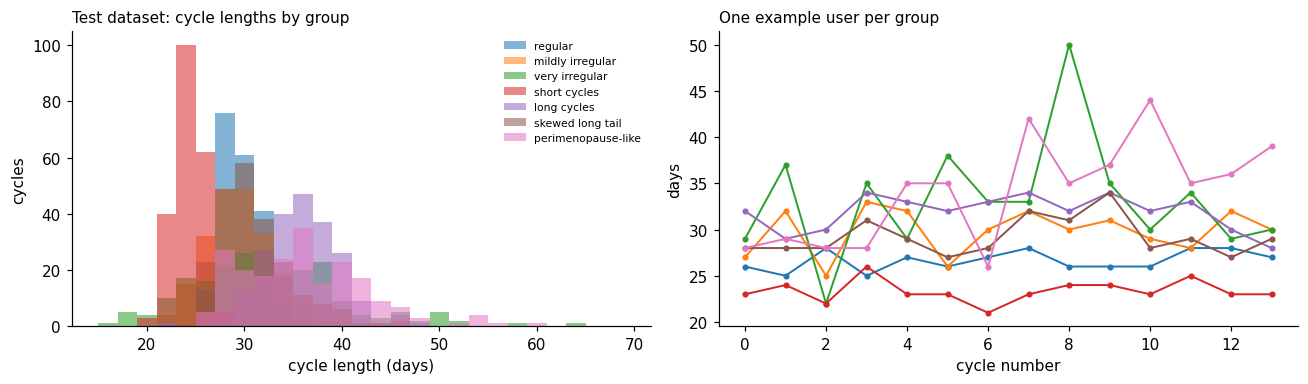

In [5]:
N_PER_PERSONA = 15      # users per group (raise for tighter numbers; slower on CPU)
N_CYCLES = 14
rng = np.random.default_rng(20261004)

def gen_user(persona):
    if persona == "regular":
        mu, s = rng.normal(28, 1.5), 1.0
        L = rng.normal(mu, s, N_CYCLES); age = "25-34"
    elif persona == "mildly irregular":
        mu, s = rng.normal(29, 2.5), 2.5
        L = rng.normal(mu, s, N_CYCLES); age = "25-34"
    elif persona == "very irregular":
        mu, s = rng.normal(31, 4), 5.0
        L = rng.normal(mu, s, N_CYCLES)
        L += (rng.random(N_CYCLES) < 0.10) * rng.integers(10, 25, N_CYCLES); age = "18-24"
    elif persona == "short cycles":
        mu, s = rng.normal(24, 1.2), 1.2
        L = rng.normal(mu, s, N_CYCLES); age = "25-34"
    elif persona == "long cycles":
        mu, s = rng.normal(35, 2.5), 3.0
        L = rng.normal(mu, s, N_CYCLES); age = "35-44"
    elif persona == "skewed long tail":
        L = rng.normal(27, 1.5) + rng.gamma(1.6, 2.6, N_CYCLES)   # mostly near the base, sometimes much longer
        age = "25-34"
    else:  # perimenopause-like drift
        mu = rng.normal(28, 1.5)
        L = mu + 1.2 * np.arange(N_CYCLES) + rng.normal(0, 1, N_CYCLES) * np.linspace(1, 6, N_CYCLES); age = "45+"
    return np.clip(np.round(L), 15, 90).astype(int), age

PERSONAS = ["regular", "mildly irregular", "very irregular", "short cycles", "long cycles", "skewed long tail", "perimenopause-like"]
rows = []
for p in PERSONAS:
    for i in range(N_PER_PERSONA):
        L, age = gen_user(p)
        uid = f"{p.split()[0][:4]}-{i:02d}"
        for j, v in enumerate(L):
            rows.append((uid, p, age, j, int(v)))
data = pd.DataFrame(rows, columns=["user_id", "persona", "age_group", "cycle_index", "cycle_length"])
data.to_csv("aadya_play_testset.csv", index=False)
print(f"{data.user_id.nunique()} users, {len(data)} cycles. Saved aadya_play_testset.csv")
display(data.head(8))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for p in PERSONAS:
    axes[0].hist(data[data.persona == p].cycle_length, bins=np.arange(15, 70, 2), alpha=0.55, label=p)
axes[0].set_xlabel("cycle length (days)"); axes[0].set_ylabel("cycles"); axes[0].legend(fontsize=7, frameon=False)
axes[0].set_title("Test dataset: cycle lengths by group", fontsize=10, loc="left")
for p in PERSONAS:
    u = data[data.persona == p].user_id.iloc[0]
    d = data[data.user_id == u]
    axes[1].plot(d.cycle_index, d.cycle_length, "o-", ms=3, lw=1.3, label=p)
axes[1].set_xlabel("cycle number"); axes[1].set_ylabel("days")
axes[1].set_title("One example user per group", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "01_testset"); plt.show()

## 5. Score the model

For every user and several points in their history, the model sees only the **past** cycles and predicts the **next** one. We compare it with three simple methods and score all of them with **CRPS** (mean error of a full probability forecast; lower is better):

- **28-day rule**: always 28.
- **Usual tracker method**: the median of the last 3 cycles.
- **Gaussian smoother**: a bell curve around the recent average, widened by how irregular the history is (the simplest honest probabilistic baseline).

**Fair warning:** most groups in this test set are drawn from bell curves, which is exactly what the Gaussian smoother assumes, so that baseline is at its best here and may match or slightly beat aadya-m1 on those. The skewed group is deliberately not a bell curve, and the model's strengths show up where real life is messier: skewed or very long cycles, forgotten logs, short histories. The numbers are printed as they come out, whatever they are.

In [6]:
def crps(pmf, y):
    return float(np.sum((np.cumsum(pmf) - (ks >= y)) ** 2))

def point_pmf(v):
    p = np.zeros(K); p[int(np.clip(round(v), 1, K)) - 1] = 1.0; return p

def gauss_pmf(mu, sd):
    w_ = np.exp(-0.5 * ((ks - mu) / sd) ** 2) + 1e-12
    return w_ / w_.sum()

def baselines(hist):
    h = list(hist)
    med3 = np.median(h[-3:]) if h else 28
    if len(h) >= 2:
        mu, sd = np.mean(h[-6:]), max(np.std(h[-6:], ddof=1), 2.0)
    else:
        mu, sd = (h[0] if h else 28), 4.5
    return {"28-day rule": point_pmf(28), "Usual tracker method": point_pmf(med3), "Gaussian smoother": gauss_pmf(mu, sd)}

def pit_value(pmf, y, u):
    cdf = np.cumsum(pmf)
    return float((cdf[y - 2] if y >= 2 else 0.0) + u * pmf[y - 1])

def median_of(pmf):
    return int(np.searchsorted(np.cumsum(pmf), 0.5) + 1)

POINTS = (3, 5, 7, 9, 11)   # history sizes at which we forecast

def evaluate(df, points=POINTS, age=True):
    recs = []
    rng_ = np.random.default_rng(1)
    users = df.user_id.unique()
    t0 = time.time()
    for n, uid in enumerate(users):
        d = df[df.user_id == uid].sort_values("cycle_index")
        L = d.cycle_length.tolist()
        ag = d.age_group.iloc[0] if age and "age_group" in d else None
        persona = d.persona.iloc[0] if "persona" in d else "all"
        for t in points:
            if t >= len(L):
                continue
            hist, y = L[:t], L[t]
            pmf = model.forecast(hist, 0, ag)
            lo, hi = model.window(pmf)
            r = {"user": uid, "persona": persona, "t": t, "y": y, "aadya-m1": crps(pmf, y),
                 "width80": hi - lo + 1, "covered": int(lo <= y <= hi), "pit": pit_value(pmf, y, rng_.random()),
                 "abs_err_median": abs(median_of(pmf) - y)}
            for name, b in baselines(hist).items():
                r[name] = crps(b, y)
                blo, bhi = model.window(b)
                r[name + " abs_err"] = abs(median_of(b) - y)
            recs.append(r)
        if n % 20 == 0:
            print(f"  {n + 1}/{len(users)} users, {time.time() - t0:.0f}s", flush=True)
    return pd.DataFrame(recs)

res = evaluate(data)
METHODS = ["aadya-m1", "Gaussian smoother", "Usual tracker method", "28-day rule"]
print(f"{len(res)} forecasts scored")

  1/105 users, 0s
  21/105 users, 3s
  41/105 users, 5s
  61/105 users, 7s
  81/105 users, 9s
  101/105 users, 12s
525 forecasts scored


,mean error (CRPS),vs usual tracker method
Gaussian smoother,2.030,+31%
aadya-m1,2.058,+30%
Usual tracker method,2.935,+0%
28-day rule,4.916,-67%


aadya-m1 minus Gaussian smoother     : +0.028  95% CI [-0.024, +0.082]  -> no clear difference
aadya-m1 minus Usual tracker method  : -0.878  95% CI [-1.064, -0.696]  -> aadya-m1 better
aadya-m1 minus 28-day rule           : -2.858  95% CI [-3.321, -2.388]  -> aadya-m1 better


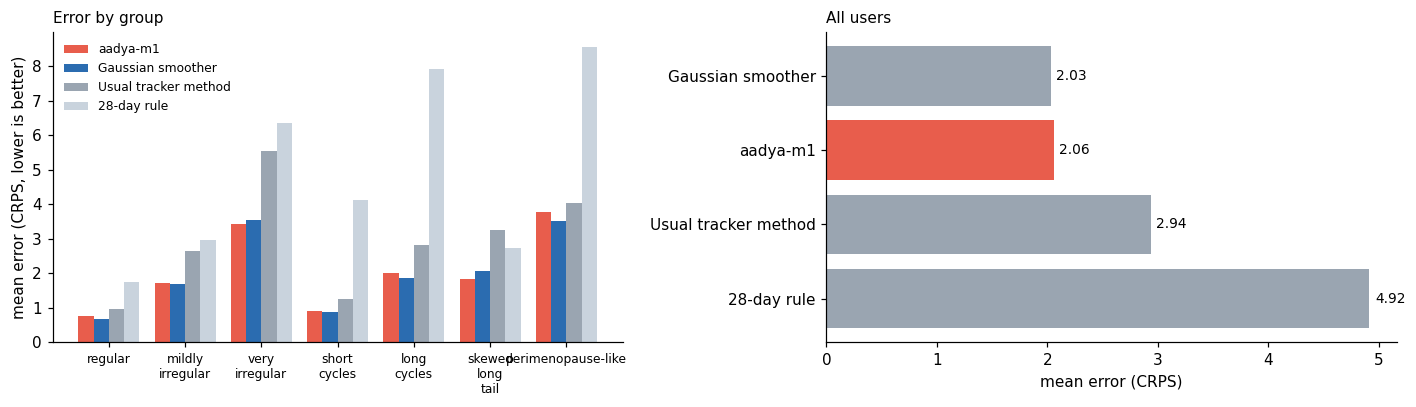

In [7]:
summary = pd.DataFrame({"mean error (CRPS)": res[METHODS].mean()}).sort_values("mean error (CRPS)")
summary["vs usual tracker method"] = (1 - summary["mean error (CRPS)"] / res["Usual tracker method"].mean()).map("{:+.0%}".format)
display(summary.round(3))

# paired bootstrap over users: is the difference real?
def paired_ci(a, b, B=2000):
    d = (res.groupby("user")[a].mean() - res.groupby("user")[b].mean()).values
    g = np.random.default_rng(7)
    bs = [g.choice(d, len(d)).mean() for _ in range(B)]
    return d.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

for b in METHODS[1:]:
    m, lo_, hi_ = paired_ci("aadya-m1", b)
    verdict = "aadya-m1 better" if hi_ < 0 else ("aadya-m1 worse" if lo_ > 0 else "no clear difference")
    print(f"aadya-m1 minus {b:22s}: {m:+.3f}  95% CI [{lo_:+.3f}, {hi_:+.3f}]  -> {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
by = res.groupby("persona")[METHODS].mean().loc[PERSONAS]
x = np.arange(len(PERSONAS)); wd = 0.2
cols = [CORAL, BLUE, GREY, "#c9d3dd"]
for i, m in enumerate(METHODS):
    axes[0].bar(x + (i - 1.5) * wd, by[m], wd, color=cols[i], label=m)
axes[0].set_xticks(x); axes[0].set_xticklabels([p.replace(" ", "\n") for p in PERSONAS], fontsize=8)
axes[0].set_ylabel("mean error (CRPS, lower is better)"); axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title("Error by group", fontsize=10, loc="left")
tot = res[METHODS].mean().sort_values()
axes[1].barh(tot.index[::-1], tot.values[::-1], color=[CORAL if m == "aadya-m1" else GREY for m in tot.index[::-1]])
for i, v in enumerate(tot.values[::-1]):
    axes[1].text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)
axes[1].set_title("All users", fontsize=10, loc="left"); axes[1].set_xlabel("mean error (CRPS)")
plt.tight_layout(); save(fig, "02_scores"); plt.show()

## 6. Is the uncertainty honest? (calibration)

A good forecast that says "8 in 10 chance" should be right about 8 times in 10. The left plot checks each stated level; the right plot is the PIT histogram, which should be roughly flat.

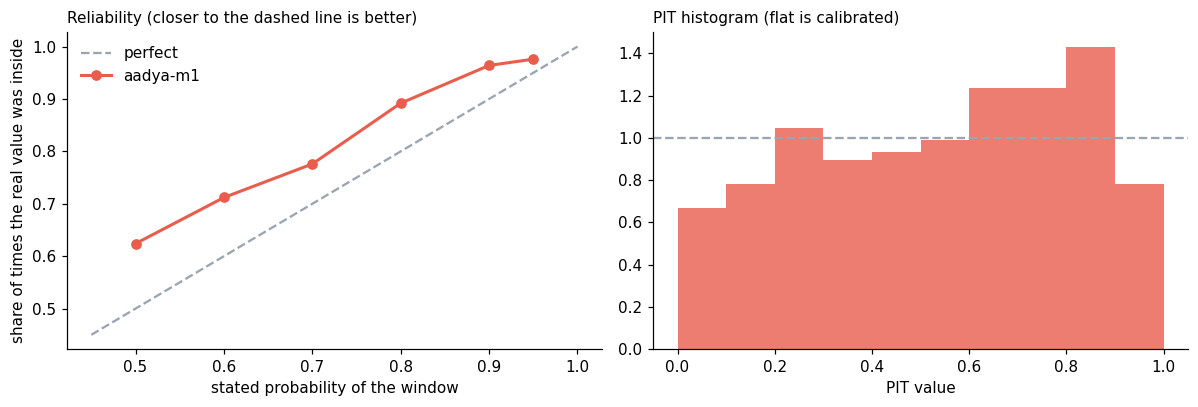

80% window contained the real value 90% of the time; average width 10.4 days


In [8]:
levels = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 0.95])
def coverage_at(df, level):
    hits = []
    for uid, t, y in zip(df.user, df.t, df.y):
        L = data[data.user_id == uid].sort_values("cycle_index").cycle_length.tolist()
        ag = data[data.user_id == uid].age_group.iloc[0]
        pmf = model.forecast(L[:t], 0, ag)
        lo_, hi_ = model.window(pmf, level)
        hits.append(lo_ <= y <= hi_)
    return float(np.mean(hits))

sub = res.sample(min(len(res), 250), random_state=3)
cov = [coverage_at(sub, lv) for lv in levels]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot([0.45, 1], [0.45, 1], "--", color=GREY, label="perfect")
axes[0].plot(levels, cov, "o-", color=CORAL, lw=2, label="aadya-m1")
axes[0].set_xlabel("stated probability of the window"); axes[0].set_ylabel("share of times the real value was inside")
axes[0].legend(frameon=False); axes[0].set_title("Reliability (closer to the dashed line is better)", fontsize=10, loc="left")
axes[1].hist(res.pit, bins=10, range=(0, 1), color=CORAL, alpha=0.8, density=True)
axes[1].axhline(1, color=GREY, ls="--")
axes[1].set_xlabel("PIT value"); axes[1].set_title("PIT histogram (flat is calibrated)", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "03_calibration"); plt.show()
print(f"80% window contained the real value {res.covered.mean():.0%} of the time; average width {res.width80.mean():.1f} days")

## 7. Short histories (cold start)

What happens with no history, or with only one or two logged cycles? The model should be wide and honest, then sharpen as data arrives.

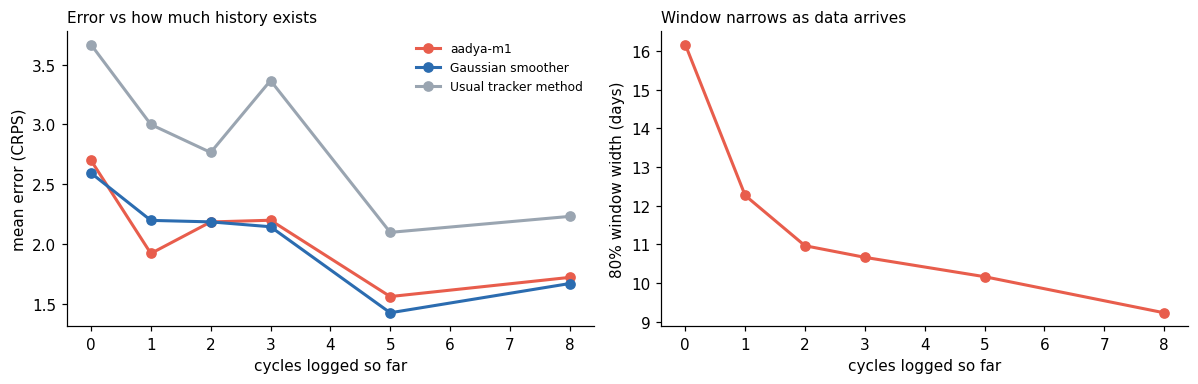

,aadya-m1,Usual tracker method,Gaussian smoother,width
cycles logged,,,,
0,2.70,3.67,2.59,16.17
1,1.92,3.00,2.20,12.27
2,2.19,2.77,2.19,10.97
3,2.20,3.37,2.15,10.67
5,1.56,2.10,1.43,10.17
8,1.72,2.23,1.67,9.23


In [9]:
cs_users = data.user_id.unique()[::3][:30]
sizes = [0, 1, 2, 3, 5, 8]
cs = []
for uid in cs_users:
    d = data[data.user_id == uid].sort_values("cycle_index")
    L = d.cycle_length.tolist(); ag = d.age_group.iloc[0]
    for h in sizes:
        pmf = model.forecast(L[:h], 0, ag); lo_, hi_ = model.window(pmf)
        b = baselines(L[:h])
        cs.append({"cycles logged": h, "aadya-m1": crps(pmf, L[h]), "Usual tracker method": crps(b["Usual tracker method"], L[h]),
                   "Gaussian smoother": crps(b["Gaussian smoother"], L[h]), "width": hi_ - lo_ + 1})
cs = pd.DataFrame(cs).groupby("cycles logged").mean()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for m, c in (("aadya-m1", CORAL), ("Gaussian smoother", BLUE), ("Usual tracker method", GREY)):
    axes[0].plot(cs.index, cs[m], "o-", color=c, lw=2, label=m)
axes[0].set_xlabel("cycles logged so far"); axes[0].set_ylabel("mean error (CRPS)"); axes[0].legend(frameon=False, fontsize=8)
axes[0].set_title("Error vs how much history exists", fontsize=10, loc="left")
axes[1].plot(cs.index, cs.width, "o-", color=CORAL, lw=2)
axes[1].set_xlabel("cycles logged so far"); axes[1].set_ylabel("80% window width (days)")
axes[1].set_title("Window narrows as data arrives", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "04_cold_start"); plt.show()
display(cs.round(2))

## 8. Forgotten period logs

Real people forget to log a period. When that happens two cycles get merged into one very long cycle. Here we corrupt the history on purpose (but score against the true next cycle) to see how much each method suffers.

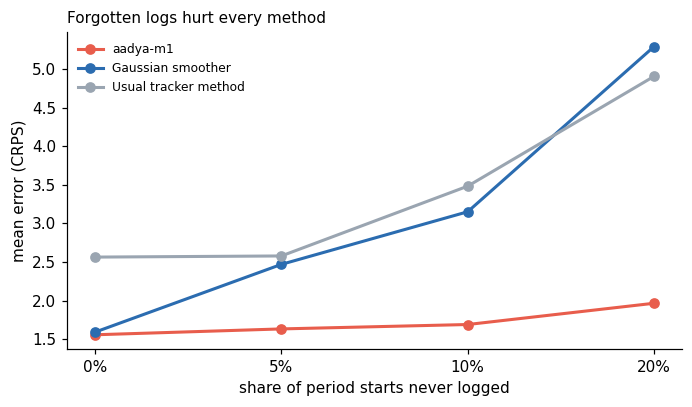

,aadya-m1,Usual tracker method,Gaussian smoother
0.00,1.56,2.56,1.59
0.05,1.63,2.58,2.47
0.10,1.69,3.48,3.15
0.20,1.97,4.90,5.29


Takeaway: an app should ask 'did you forget to log a period?' when a cycle looks unusually long.


In [10]:
def corrupt(L, p, g):
    out, carry = [], 0
    for v in L:
        if g.random() < p:
            carry += v
        else:
            out.append(v + carry); carry = 0
    return out

levels_p = [0.0, 0.05, 0.10, 0.20]
g = np.random.default_rng(11)
mu_users = data.user_id.unique()[::2][:45]
mr = {p: {"aadya-m1": [], "Usual tracker method": [], "Gaussian smoother": []} for p in levels_p}
for uid in mu_users:
    d = data[data.user_id == uid].sort_values("cycle_index")
    L = d.cycle_length.tolist(); ag = d.age_group.iloc[0]
    for t in (6, 9, 12):
        for p in levels_p:
            hist = corrupt(L[:t], p, g) or [L[0]]
            pmf = model.forecast(hist, 0, ag); b = baselines(hist)
            mr[p]["aadya-m1"].append(crps(pmf, L[t]))
            mr[p]["Usual tracker method"].append(crps(b["Usual tracker method"], L[t]))
            mr[p]["Gaussian smoother"].append(crps(b["Gaussian smoother"], L[t]))
mr_df = pd.DataFrame({p: {m: np.mean(v) for m, v in d_.items()} for p, d_ in mr.items()}).T
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for m, c in (("aadya-m1", CORAL), ("Gaussian smoother", BLUE), ("Usual tracker method", GREY)):
    ax.plot([f"{int(p * 100)}%" for p in mr_df.index], mr_df[m], "o-", color=c, lw=2, label=m)
ax.set_xlabel("share of period starts never logged"); ax.set_ylabel("mean error (CRPS)"); ax.legend(frameon=False, fontsize=8)
ax.set_title("Forgotten logs hurt every method", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "05_missed_logs"); plt.show()
display(mr_df.round(2))
print("Takeaway: an app should ask 'did you forget to log a period?' when a cycle looks unusually long.")

## 9. Forecast sharpening during a cycle

As days pass without a period, the possible lengths shrink. Watch the same history at different days.

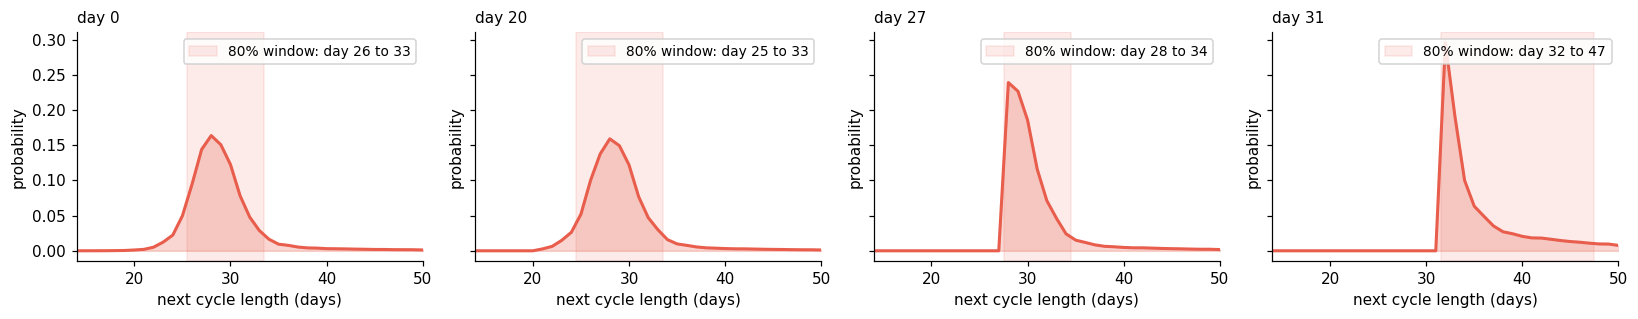

In [11]:
hist = [28, 29, 27, 30, 28]
fig, axes = plt.subplots(1, 4, figsize=(15, 3), sharey=True)
for ax, day in zip(axes, (0, 20, 27, 31)):
    plot_forecast(hist, day, ax=ax, title=f"day {day}")
    ax.set_xlim(14, 50)
plt.tight_layout(); save(fig, "06_sharpening"); plt.show()

## 10. Optional ovulation-test input (experimental)

If the user logs the day an ovulation test showed the surge had passed, the next-period window can narrow. In the model this never produces an ovulation date or a fertile window.

**Important:** the ovulation tests below are *synthetic* and are drawn from the same luteal-phase assumption the model uses, so this section shows that the mechanism works, not how large the gain is for real people. On a small real study (41 participants) the 80% window went from about 12 to about 7 days.

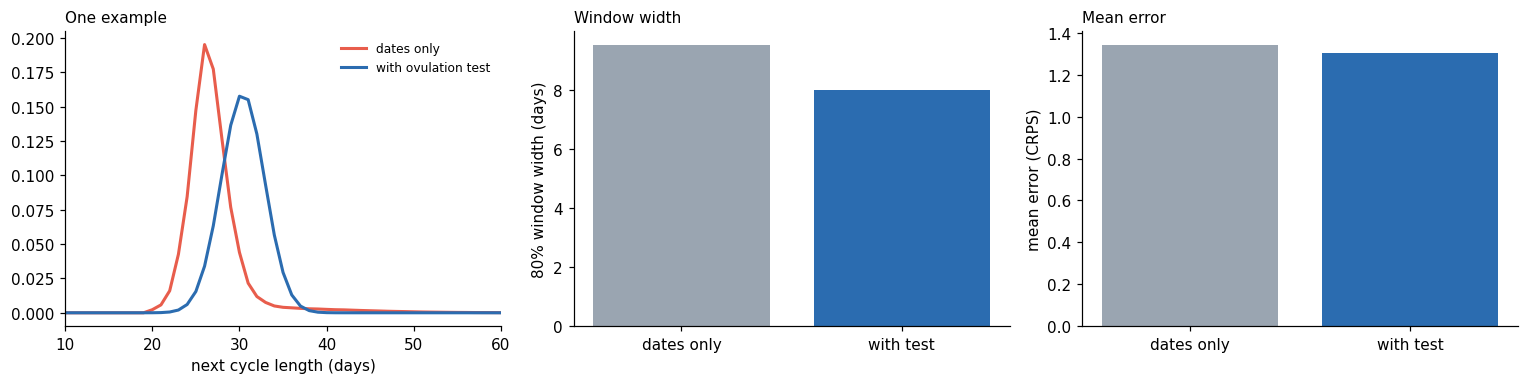

45 synthetic cycles: window 9.5 -> 8.0 days, error 1.34 -> 1.30


In [12]:
g = np.random.default_rng(5)
mk_rows = []
for uid in data.user_id.unique()[::2][:45]:
    d = data[data.user_id == uid].sort_values("cycle_index")
    L = d.cycle_length.tolist(); ag = d.age_group.iloc[0]
    t = 7; y = L[t]
    remaining = int(np.clip(round(g.normal(11.4, 2.5)), 6, 20))
    m = y - remaining
    if m < 8 or m >= y:
        continue
    base = model.forecast(L[:t], m, ag)
    withm = model.forecast(L[:t], m, ag, ovulation_test_day=m)
    b = baselines(L[:t])["Usual tracker method"]
    wlo, whi = model.window(withm); blo, bhi = model.window(base)
    mk_rows.append({"y": y, "day_logged": m, "crps_dates_only": crps(base, y), "crps_with_test": crps(withm, y),
                    "width_dates_only": bhi - blo + 1, "width_with_test": whi - wlo + 1})
mk = pd.DataFrame(mk_rows)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ex = mk.iloc[0]; d0 = data[data.user_id == data.user_id.unique()[0]].sort_values("cycle_index").cycle_length.tolist()
p1 = model.forecast(d0[:7], int(ex.day_logged), "25-34"); p2 = model.forecast(d0[:7], int(ex.day_logged), "25-34", ovulation_test_day=int(ex.day_logged))
axes[0].plot(ks, p1, color=CORAL, lw=2, label="dates only"); axes[0].plot(ks, p2, color=BLUE, lw=2, label="with ovulation test")
axes[0].set_xlim(10, 60); axes[0].legend(frameon=False, fontsize=8); axes[0].set_xlabel("next cycle length (days)")
axes[0].set_title("One example", fontsize=10, loc="left")
axes[1].bar(["dates only", "with test"], [mk.width_dates_only.mean(), mk.width_with_test.mean()], color=[GREY, BLUE])
axes[1].set_ylabel("80% window width (days)"); axes[1].set_title("Window width", fontsize=10, loc="left")
axes[2].bar(["dates only", "with test"], [mk.crps_dates_only.mean(), mk.crps_with_test.mean()], color=[GREY, BLUE])
axes[2].set_ylabel("mean error (CRPS)"); axes[2].set_title("Mean error", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "07_ovulation_test"); plt.show()
print(f"{len(mk)} synthetic cycles: window {mk.width_dates_only.mean():.1f} -> {mk.width_with_test.mean():.1f} days, error {mk.crps_dates_only.mean():.2f} -> {mk.crps_with_test.mean():.2f}")

## 11. Personalization on the device

`observe_outcome` tells the model how long a cycle really was. The learning stays in a small local state you can save, and it never leaves the device. Here one irregular user is followed cycle by cycle, with and without personalization.

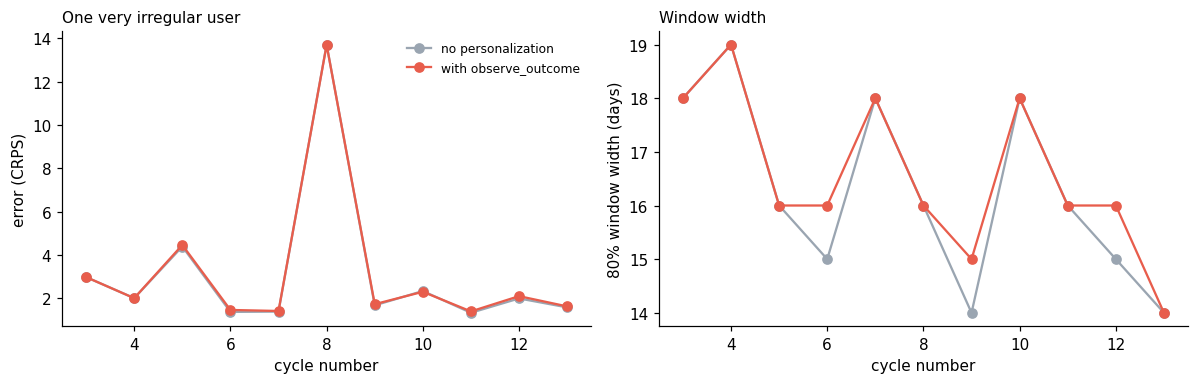

(Since the Oct 2026 update, personalization no longer widens the window; it only shifts how much the model leans on its Bayes component.)
mean error: 3.15 without, 3.19 with personalization (one user is anecdotal, not a benchmark)
state saved locally -> {
  "residuals": [
    5.0,
    -2.0,
    8.0,
    2.0,
    0.0,
    19.0,
    2.0,
    -3.0,
    1.0,
    -2.0,
    -1.0
  ],
  "crps_hist" ...


In [13]:
model_p = AadyaM1.from_pretrained(path, device=device)    # a second copy that learns
u = [x for x in data.user_id.unique() if x.startswith("very")][0]
L = data[data.user_id == u].sort_values("cycle_index").cycle_length.tolist()
pr = []
for t in range(3, len(L)):
    p_fresh = model.forecast(L[:t], 0, "18-24"); p_pers = model_p.forecast(L[:t], 0, "18-24")
    pr.append({"cycle": t, "actual": L[t], "fresh": crps(p_fresh, L[t]), "personalized": crps(p_pers, L[t]),
               "w_fresh": np.diff(model.window(p_fresh))[0] + 1, "w_pers": np.diff(model.window(p_pers))[0] + 1})
    model_p.observe_outcome(L[t])
pr = pd.DataFrame(pr)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(pr.cycle, pr.fresh, "o-", color=GREY, label="no personalization"); axes[0].plot(pr.cycle, pr.personalized, "o-", color=CORAL, label="with observe_outcome")
axes[0].set_xlabel("cycle number"); axes[0].set_ylabel("error (CRPS)"); axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(pr.cycle, pr.w_fresh, "o-", color=GREY); axes[1].plot(pr.cycle, pr.w_pers, "o-", color=CORAL)
axes[1].set_xlabel("cycle number"); axes[1].set_ylabel("80% window width (days)")
axes[0].set_title("One very irregular user", fontsize=10, loc="left"); axes[1].set_title("Window width", fontsize=10, loc="left")
plt.tight_layout(); save(fig, "08_personalization"); plt.show()
print("(Since the Oct 2026 update, personalization no longer widens the window; it only shifts how much the model leans on its Bayes component.)")
print(f"mean error: {pr.fresh.mean():.2f} without, {pr.personalized.mean():.2f} with personalization (one user is anecdotal, not a benchmark)")
model_p.export_state("local_state.json"); print("state saved locally ->", open("local_state.json").read()[:140], "...")

## 12. Edge-case and safety checks

Automatic checks that the output is always a valid probability distribution, and that bad inputs are rejected clearly.

In [14]:
def valid(pmf, elapsed=0):
    return (len(pmf) == K and np.all(np.isfinite(pmf)) and np.all(pmf >= 0) and abs(pmf.sum() - 1) < 1e-6
            and np.all(pmf[:elapsed] == 0))

cases = [
    ("no history", [], 0, None), ("one cycle", [29], 0, None), ("two cycles", [29, 31], 0, None),
    ("20 regular cycles", [28] * 20, 0, None), ("very short cycles", [15, 16, 15, 17], 0, None),
    ("very long cycles", [80, 90, 85], 0, None), ("alternating", [21, 40, 21, 40, 21, 40], 0, None),
    ("day 10 of cycle", [28, 29, 28], 10, None), ("day 35 (late)", [28, 29, 28], 35, None),
    ("day 100 (very late)", [28, 29, 28], 100, None), ("day 119", [28, 29, 28], 119, None),
]
checks = []
for name, h, e, ag in cases:
    try:
        p = model.forecast(h, e, ag); lo_, hi_ = model.window(p)
        checks.append((name, "valid distribution", "PASS" if valid(p, e) and lo_ <= hi_ else "FAIL"))
    except Exception as ex:
        checks.append((name, f"raised {type(ex).__name__}", "FAIL"))
for ag in ("18-24", "25-34", "35-44", "45+"):
    checks.append((f"age group {ag}", "valid distribution", "PASS" if valid(model.forecast([28, 30, 29], 0, ag)) else "FAIL"))
checks.append(("ovulation test day 14", "valid distribution", "PASS" if valid(model.forecast([28, 30, 29], 16, None, 14), 16) else "FAIL"))
a = model.forecast([28, 30, 29], 0, "25-34"); b = model.forecast([28, 30, 29], 0, "25-34")
checks.append(("same input twice", "identical output", "PASS" if np.array_equal(a, b) else "FAIL"))

def raises(fn):
    try: fn(); return False
    except (ValueError, TypeError): return True
checks.append(("invalid age group", "rejected", "PASS" if raises(lambda: model.forecast([28], 0, "99-100")) else "FAIL"))
checks.append(("negative cycle length", "rejected", "PASS" if raises(lambda: model.forecast([28, -3], 0)) else "FAIL"))
checks.append(("ovulation test in the future", "rejected", "PASS" if raises(lambda: model.forecast([28, 30], 5, None, 12)) else "FAIL"))
checks.append(("window level 1.5", "rejected", "PASS" if raises(lambda: model.window(a, 1.5)) else "FAIL"))
chk = pd.DataFrame(checks, columns=["case", "expectation", "result"])
display(chk)
print(f"{(chk.result == 'PASS').sum()} of {len(chk)} checks passed")

,case,expectation,result
0,no history,valid distribution,PASS
1,one cycle,valid distribution,PASS
2,two cycles,valid distribution,PASS
3,20 regular cycles,valid distribution,PASS
4,very short cycles,valid distribution,PASS
5,very long cycles,valid distribution,PASS
6,alternating,valid distribution,PASS
7,day 10 of cycle,valid distribution,PASS
8,day 35 (late),valid distribution,PASS
9,day 100 (very late),valid distribution,PASS


21 of 21 checks passed


## 13. Test with your own data

Upload a CSV with the columns `user_id, cycle_index, cycle_length` (optional: `age_group`). It must contain only **your own or properly consented** data; the file is processed inside this Colab session only. If you skip the upload, the cell does nothing.

In [15]:
try:
    from google.colab import files
    up = files.upload()
    if up:
        mine = pd.read_csv(next(iter(up)))
        if "age_group" not in mine: mine["age_group"] = None
        mres = evaluate(mine, points=(2, 3, 4, 5, 6, 7), age=False)
        display(mres[["aadya-m1", "Gaussian smoother", "Usual tracker method", "28-day rule"]].mean().round(3).to_frame("mean error (CRPS)"))
except ImportError:
    print("Not in Colab: use evaluate(your_dataframe) directly.")

Saving sample_my_cycles.csv to sample_my_cycles.csv
  1/4 users, 0s


,mean error (CRPS)
aadya-m1,1.483
Gaussian smoother,1.553
Usual tracker method,2.625
28-day rule,3.875


## 14. Scorecard and downloads

In [16]:
score = {
    "forecasts scored": len(res),
    "aadya-m1 mean error": round(res["aadya-m1"].mean(), 3),
    "usual tracker method": round(res["Usual tracker method"].mean(), 3),
    "error removed vs usual method": f"{1 - res['aadya-m1'].mean() / res['Usual tracker method'].mean():.0%}",
    "80% window coverage": f"{res.covered.mean():.0%}",
    "average 80% window (days)": round(res.width80.mean(), 1),
    "edge-case checks passed": f"{(chk.result == 'PASS').sum()}/{len(chk)}",
}
display(pd.Series(score, name="value").to_frame())
res.to_csv(f"{OUT}/results_per_forecast.csv", index=False)
import shutil
shutil.copy("aadya_play_testset.csv", OUT)
shutil.make_archive("aadya_results", "zip", OUT)
try:
    from google.colab import files
    files.download("aadya_results.zip")
except Exception:
    print("Results saved in", OUT, "and aadya_results.zip")

,value
forecasts scored,525
aadya-m1 mean error,2.058
usual tracker method,2.935
error removed vs usual method,30%
80% window coverage,90%
average 80% window (days),10.4
edge-case checks passed,21/21


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Reading these results honestly
- If the Gaussian smoother is level with or slightly ahead of aadya-m1 in section 5, that is expected on bell-curve test data; the model's edge is in messier cases such as forgotten logs (section 8).
- The test data is synthetic. It shows how the model behaves, not how it performs for real people. On small public real-data cohorts, aadya-m1 has the lowest mean error, and its lead over the classical Bayes reference there is small and within noise (see the model card).
- No forecast is a guarantee. Always show the whole window, not one date.
- Not a medical device: no diagnosis, no contraception or fertility advice, no "safe days".

Model: https://huggingface.co/manasdutta04/aadya-m1 | Contribute: https://github.com/manasdutta04/aadya